In [ ]:
!pip install pretty_midi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 38.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.7 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=f6847c67efe379fc86e111e1f6349f475ab36b64aabddf76906fc0b165c100a0
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dataset contents:
pop
reggae
metal
hiphop
jazz
disco
country
classical
blues

Sample files from pop:
pop.00008.wav
pop.00022.wav
pop.00000.wav
pop.00012.wav
pop.00015.wav
... and 62 more


100%|██████████| 9/9 [04:06<00:00, 27.44s/it]


Shape: (728, 13)
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0000e+00
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00
Epoch 13/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00
Epoch 14/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00
Epoch 15/50


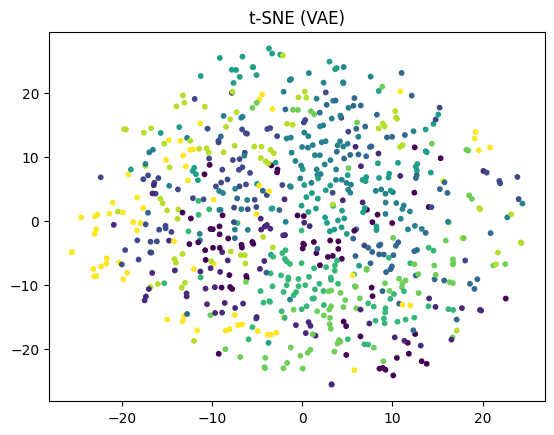

In [ ]:
#425_Easy_Task
# =======================
# NODE 1: CHECK DATASET
# =======================
"""425_Easy_task.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/137ovynduBRDvXIwqAmc894-_L-0oTK3W"""

import os

DATASET_PATH = '/content/drive/MyDrive/CSE425/genres_original'

def check_dataset(path):
    if not os.path.exists(path):
        print(f"Error: {path} not found")
        return False

    print(f"Dataset contents:")
    for item in os.listdir(path):
        print(item)

    subdirs = [os.path.join(path, d) for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    if subdirs:
        sample = subdirs[0]
        print(f"\nSample files from {os.path.basename(sample)}:")
        files = os.listdir(sample)
        for i, f in enumerate(files[:5]):
            print(f)
        if len(files) > 5:
            print(f"... and {len(files)-5} more")

    return True

if not check_dataset(DATASET_PATH):
    exit()


# =======================
# NODE 2: IMPORTS
# =======================
import warnings
warnings.filterwarnings("ignore")

!pip install librosa

import numpy as np
import librosa
from tqdm import tqdm


# =======================
# NODE 3: FEATURE EXTRACTION
# =======================
def extract_mfcc(file_path, n_mfcc=13, duration=30):
    try:
        y, sr = librosa.load(file_path, duration=duration)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return np.mean(mfcc.T, axis=0)
    except:
        return None


def build_dataset(path):
    X, y = [], []

    for genre in tqdm(os.listdir(path)):
        genre_path = os.path.join(path, genre)

        if not os.path.isdir(genre_path):
            continue

        for file in os.listdir(genre_path):
            if file.endswith('.wav'):
                mfcc = extract_mfcc(os.path.join(genre_path, file))
                if mfcc is not None:
                    X.append(mfcc)
                    y.append(genre)

    return np.array(X), np.array(y)


X, y_labels = build_dataset(DATASET_PATH)

print("Shape:", X.shape)


# =======================
# NODE 4: NORMALIZATION
# =======================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

np.save('mfcc_features_scaled.npy', X_scaled)


# =======================
# NODE 5: BUILD VAE
# =======================
import tensorflow as tf
from tensorflow.keras import layers, Model

input_dim = X_scaled.shape[1]
latent_dim = 16

def sampling(args):
    z_mean, z_log_var = args
    eps = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * eps


# Encoder
inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z])

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(32, activation='relu')(latent_inputs)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(input_dim)(x)

decoder = Model(latent_inputs, outputs)


# =======================
# NODE 6: TRAIN VAE
# =======================
class VAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            recon = self.decoder(z)

            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(data - recon), axis=1))
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )

            loss = recon_loss + kl_loss

        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {"loss": loss}


vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')
vae.fit(X_scaled, epochs=50, batch_size=32, shuffle=True)


# =======================
# NODE 7: LATENT SPACE
# =======================
z_mean, z_log_var, z = encoder.predict(X_scaled)


# =======================
# NODE 8: KMEANS (VAE)
# =======================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

kmeans_vae = KMeans(n_clusters=10, random_state=42)
vae_clusters = kmeans_vae.fit_predict(z)

print("VAE Scores:")
print(silhouette_score(z, vae_clusters))
print(calinski_harabasz_score(z, vae_clusters))


# =======================
# NODE 9: PCA + KMEANS
# =======================
from sklearn.decomposition import PCA

X_pca = PCA(n_components=13).fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=10, random_state=42)
pca_clusters = kmeans_pca.fit_predict(X_pca)

print("PCA Scores:")
print(silhouette_score(X_pca, pca_clusters))
print(calinski_harabasz_score(X_pca, pca_clusters))


# =======================
# NODE 10: TSNE VISUALIZATION
# =======================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

z_tsne = TSNE(n_components=2, random_state=42).fit_transform(z)

plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=vae_clusters, s=10)
plt.title("t-SNE (VAE)")
plt.show()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Device: cpu
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae']
Total .wav files: 729
[Dataset] Loaded 728 files, skipped 1
Train: 582 Val: 146
Epoch 1: Train 30430.5710 | Val 23528.1469
Epoch 2: Train 22368.4301 | Val 20433.9762
Epoch 3: Train 19213.6859 | Val 16777.6020
Epoch 4: Train 16531.6569 | Val 15574.3762
Epoch 5: Train 15992.6020 | Val 15024.2168
Epoch 6: Train 15021.5292 | Val 14220.0014
Epoch 7: Train 14242.6035 | Val 13708.1057
Epoch 8: Train 13673.2677 | Val 13548.1627
Epoch 9: Train 13416.5310 | Val 13149.0463
Epoch 10: Train 12966.7731 | Val 12803.4307
Epoch 11: Train 12829.1395 | Val 12608.0604
Epoch 12: Train 12623.0447 | Val 12607.3918
Epoch 13: Train 12512.1935 | Val 12479.9479
Epoch 14: Train 12343.7014 | Val 12422.7924
Epoch 15: Train 1

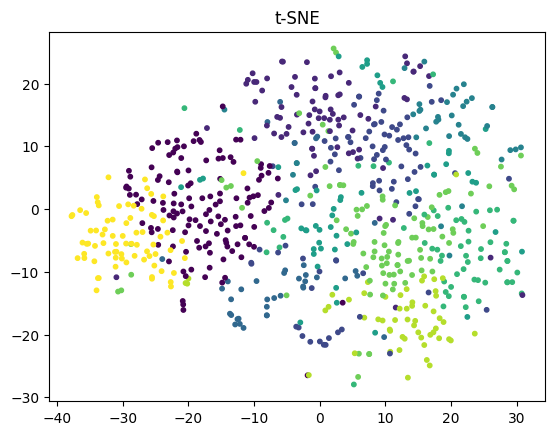

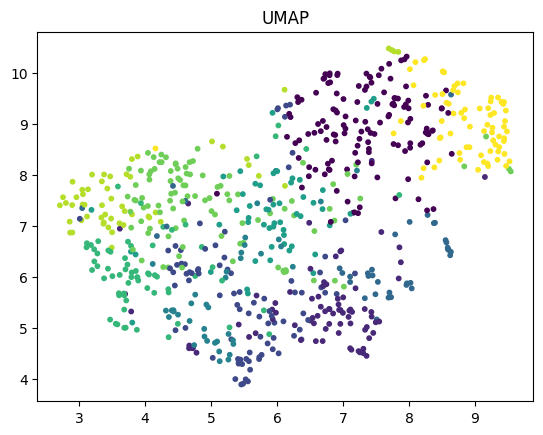

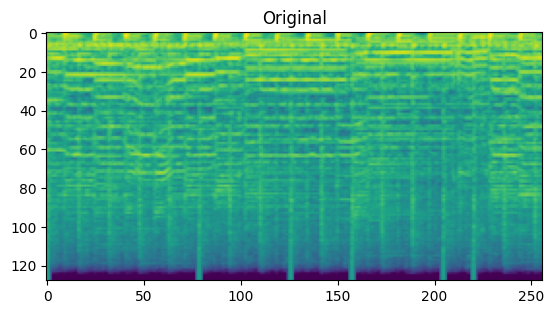

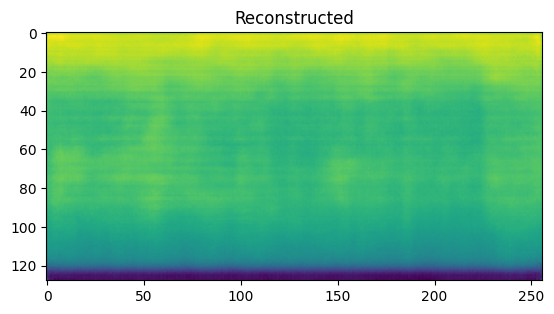

In [ ]:
# =========================================================
# NODE 1: ENVIRONMENT SETUP
# =========================================================

"""425_Medium_task.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/137ovynduBRDvXIwqAmc894-_L-0oTK3W"""

!pip -q install librosa tqdm umap-learn soundfile audioread
!apt-get -qq update
!apt-get -qq install -y ffmpeg libsndfile1

import os, random, numpy as np
from tqdm import tqdm
import librosa, soundfile as sf

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from sklearn.manifold import TSNE
import umap

import matplotlib.pyplot as plt


# =========================================================
# NODE 2: SEED + DEVICE
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# =========================================================
# NODE 3: DATASET CHECK
# =========================================================
DATASET_PATH = "/content/drive/MyDrive/CSE425/genres_original"

genres = sorted([g for g in os.listdir(DATASET_PATH)
                 if os.path.isdir(os.path.join(DATASET_PATH, g))])

print("Genres:", genres)

total = sum(len([f for f in os.listdir(os.path.join(DATASET_PATH, g)) if f.endswith(".wav")])
            for g in genres)

print("Total .wav files:", total)


# =========================================================
# NODE 4: FEATURE EXTRACTION (LOG-MEL)
# =========================================================
def wav_to_logmel(file_path):
    try:
        y, sr = librosa.load(file_path, sr=22050, duration=30)
    except:
        try:
            y, sr_native = sf.read(file_path)
            if y.ndim > 1:
                y = np.mean(y, axis=1)
            y = librosa.resample(y.astype(np.float32), sr_native, 22050)
        except:
            return None

    target_len = 22050 * 30
    y = np.pad(y, (0, max(0, target_len - len(y))))[:target_len]

    mel = librosa.feature.melspectrogram(y=y, sr=22050, n_mels=128)
    logmel = librosa.power_to_db(mel)
    logmel = (logmel - logmel.mean()) / (logmel.std() + 1e-8)

    logmel = logmel[:, :256] if logmel.shape[1] >= 256 else \
             np.pad(logmel, ((0,0),(0,256-logmel.shape[1])))

    return logmel.astype(np.float32)[None,:,:]


# =========================================================
# NODE 5: DATASET CLASS
# =========================================================
genre_to_id = {g:i for i,g in enumerate(genres)}

class GTZANLogMelDataset(Dataset):
    def __init__(self, root):
        self.items = []
        bad = 0

        for g in genres:
            for f in os.listdir(os.path.join(root, g)):
                if f.endswith(".wav"):
                    p = os.path.join(root, g, f)
                    x = wav_to_logmel(p)
                    if x is None:
                        bad += 1
                        continue
                    self.items.append((p, genre_to_id[g]))

        print(f"[Dataset] Loaded {len(self.items)} files, skipped {bad}")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        p, y = self.items[idx]
        x = wav_to_logmel(p)
        if x is None:
            x = np.zeros((1,128,256), dtype=np.float32)
        return torch.from_numpy(x), y, p


# =========================================================
# NODE 6: DATA LOADER
# =========================================================
ds = GTZANLogMelDataset(DATASET_PATH)

train_ds, val_ds = random_split(ds, [int(0.8*len(ds)), len(ds)-int(0.8*len(ds))])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)

print("Train:", len(train_ds), "Val:", len(val_ds))


# =========================================================
# NODE 7: MODEL (ConvVAE)
# =========================================================
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()

        self.enc = nn.Sequential(
            nn.Conv2d(1,32,4,2,1), nn.ReLU(),
            nn.Conv2d(32,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.ReLU(),
            nn.Conv2d(128,256,4,2,1)
        )

        self.fc_mu = nn.Linear(256*8*16, latent_dim)
        self.fc_logvar = nn.Linear(256*8*16, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 256*8*16)

        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256,128,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(128,64,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,2,1)
        )

    def forward(self, x):
        h = self.enc(x).view(x.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        z = mu + torch.randn_like(mu) * torch.exp(0.5*logvar)

        h2 = self.fc_dec(z).view(x.size(0),256,8,16)
        return self.dec(h2), mu, logvar, z


# =========================================================
# NODE 8: TRAINING
# =========================================================
def loss_fn(x, x_hat, mu, logvar):
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon + kl, recon, kl

model = ConvVAE().to(device)
opt = torch.optim.Adam(model.parameters(), lr=5e-4)

history_train, history_val = [], []

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_recon, total_kl = 0,0,0
    n = 0

    for x,_,_ in loader:
        x = x.to(device)

        with torch.set_grad_enabled(train):
            x_hat, mu, logvar,_ = model(x)
            loss, recon, kl = loss_fn(x,x_hat,mu,logvar)

            if train:
                opt.zero_grad()
                loss.backward()
                opt.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()
        n += 1

    return total_loss/n, total_recon/n, total_kl/n


for ep in range(1,26):
    tr = run_epoch(train_loader, True)
    va = run_epoch(val_loader, False)

    history_train.append(tr)
    history_val.append(va)

    print(f"Epoch {ep}: Train {tr[0]:.4f} | Val {va[0]:.4f}")


# =========================================================
# NODE 9: LATENT SPACE
# =========================================================
model.eval()

Z, Y = [], []

with torch.no_grad():
    for x,y,_ in DataLoader(ds, batch_size=32):
        x = x.to(device)
        _, mu, _, _ = model(x)
        Z.append(mu.cpu().numpy())
        Y.append(np.array(y))

Z = np.vstack(Z)
Y = np.concatenate(Y)

Zs = StandardScaler().fit_transform(Z)


# =========================================================
# NODE 10: CLUSTERING
# =========================================================
pred_km = KMeans(10, random_state=42).fit_predict(Zs)
pred_agg = AgglomerativeClustering(10).fit_predict(Zs)
pred_db = DBSCAN(eps=1.5, min_samples=5).fit_predict(Zs)


# =========================================================
# NODE 11: METRICS
# =========================================================
def evaluate(name, Z, pred, Y):
    mask = pred != -1 if -1 in pred else np.ones(len(pred), bool)
    if len(np.unique(pred[mask])) < 2:
        print(name, "Not valid")
        return

    print(f"\n{name}")
    print("Silhouette:", silhouette_score(Z[mask], pred[mask]))
    print("CH:", calinski_harabasz_score(Z[mask], pred[mask]))
    print("DB:", davies_bouldin_score(Z[mask], pred[mask]))
    print("ARI:", adjusted_rand_score(Y[mask], pred[mask]))

evaluate("KMeans", Zs, pred_km, Y)
evaluate("Agglomerative", Zs, pred_agg, Y)
evaluate("DBSCAN", Zs, pred_db, Y)


# =========================================================
# NODE 12: VISUALIZATION
# =========================================================
Z_tsne = TSNE(2, random_state=42).fit_transform(Zs)

plt.scatter(Z_tsne[:,0], Z_tsne[:,1], c=pred_km, s=10)
plt.title("t-SNE")
plt.show()

Z_umap = umap.UMAP().fit_transform(Zs)

plt.scatter(Z_umap[:,0], Z_umap[:,1], c=pred_km, s=10)
plt.title("UMAP")
plt.show()


# =========================================================
# NODE 13: RECONSTRUCTION
# =========================================================
x,_,_ = next(iter(val_loader))
x = x.to(device)

with torch.no_grad():
    x_hat,_,_,_ = model(x)

plt.imshow(x[0,0].cpu())
plt.title("Original")
plt.show()

plt.imshow(x_hat[0,0].cpu())
plt.title("Reconstructed")
plt.show()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Device: cpu
Genres folder exists: True
Resolved CSV_PATH: /content/drive/MyDrive/CSE425/fesmall.csv
CSV shape: (1000, 60)
CSV columns (first 10): ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var']
Example filename: blues.00000.wav label: blues
Unique labels in CSV: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'] ... total: 10
Genres in folder: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae']
Audio items aligned with CSV: 729
Audio files missing in CSV: 0
Classes: [np.str_('blues'), np.str_('classical'), np.str_('country'), np.str_('disco'), np.str_('hiphop'), np.str_('jazz'), np.st

Checking audio:  72%|███████▏  | 524/729 [03:11<01:18,  2.62it/s]/tmp/ipykernel_6614/1420552231.py:139: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _sr = librosa.load(file_path, sr=sr, duration=duration, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Checking audio: 100%|██████████| 729/729 [04:22<00:00,  2.77it/s]


[Dataset] usable=728 skipped_bad=1
x: torch.Size([1, 128, 256]) y: 0 c: torch.Size([9]) path: blues.00023.wav
Train: 582 Val: 146
Ep 01/25 | Train L=33200.37 (R=32988.86, KL=52.88) | Val L=27570.61 (R=27466.07, KL=26.14)
Ep 02/25 | Train L=24683.16 (R=24584.43, KL=24.68) | Val L=20645.28 (R=20566.26, KL=19.75)
Ep 03/25 | Train L=20913.82 (R=20820.92, KL=23.22) | Val L=19405.22 (R=19300.01, KL=26.30)
Ep 04/25 | Train L=19415.16 (R=19298.75, KL=29.10) | Val L=18601.64 (R=18485.12, KL=29.13)
Ep 05/25 | Train L=18466.63 (R=18339.04, KL=31.90) | Val L=17633.54 (R=17495.98, KL=34.39)
Ep 06/25 | Train L=17587.14 (R=17437.92, KL=37.31) | Val L=16982.44 (R=16835.28, KL=36.79)
Ep 07/25 | Train L=17134.43 (R=16977.08, KL=39.34) | Val L=16816.07 (R=16649.67, KL=41.60)
Ep 08/25 | Train L=16913.21 (R=16749.88, KL=40.83) | Val L=16791.61 (R=16614.56, KL=44.26)
Ep 09/25 | Train L=16860.92 (R=16695.63, KL=41.32) | Val L=16485.89 (R=16306.74, KL=44.79)
Ep 10/25 | Train L=16518.96 (R=16351.28, KL=41.92) 

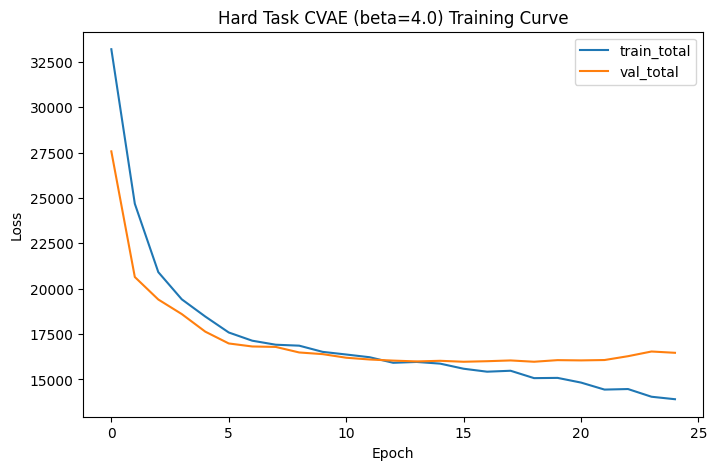

Extracting latents: 100%|██████████| 23/23 [01:15<00:00,  3.28s/it]


Z shape: (728, 16) Y shape: (728,)
Zs mean: -3.2749806e-10 Zs std: 1.0

Hard CVAE Latent + KMeans
Silhouette: 0.052749723
Calinski-Harabasz: 33.56763
Davies-Bouldin (lower better): 2.440857398069703
ARI: 0.04485109315373385
NMI: 0.09657396063016563
Purity: 0.2857142857142857

Hard CVAE Latent + Agglomerative
Silhouette: 0.014050171
Calinski-Harabasz: 25.980097
Davies-Bouldin (lower better): 2.838491085973754
ARI: 0.0329168225248917
NMI: 0.08907912736955827
Purity: 0.25824175824175827


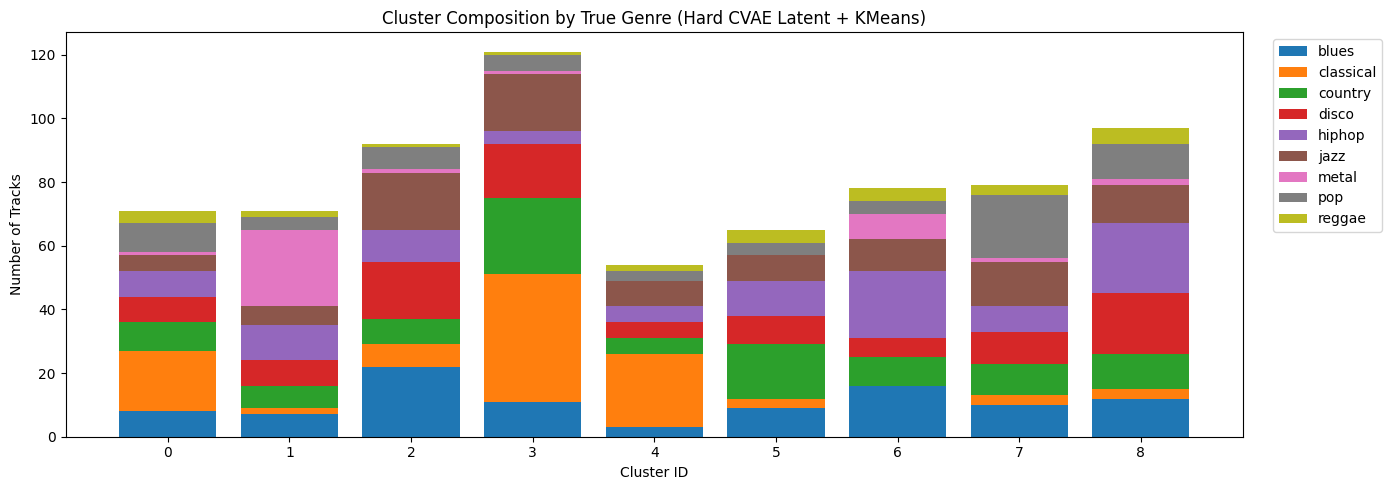


Per-cluster purity and dominant genre:
Cluster  0: size=  71  dominant=classical   purity=0.268
Cluster  1: size=  71  dominant=metal       purity=0.338
Cluster  2: size=  92  dominant=blues       purity=0.239
Cluster  3: size= 121  dominant=classical   purity=0.331
Cluster  4: size=  54  dominant=classical   purity=0.426
Cluster  5: size=  65  dominant=country     purity=0.262
Cluster  6: size=  78  dominant=hiphop      purity=0.269
Cluster  7: size=  79  dominant=pop         purity=0.253
Cluster  8: size=  97  dominant=hiphop      purity=0.227

β SWEEP START

--------------------
Training for beta = 1.0
beta=1.0  ep=01/10  train_loss=34373.2  val_loss=31568.5
beta=1.0  ep=05/10  train_loss=19078.0  val_loss=18252.8
beta=1.0  ep=10/10  train_loss=16538.6  val_loss=16329.3
Metrics: {'ARI': 0.04059562688560928, 'NMI': np.float64(0.10383550523160998), 'Purity': np.float64(0.2733516483516483), 'Silhouette': np.float32(0.12065973)}

--------------------
Training for beta = 2.0
beta=2.0  e

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


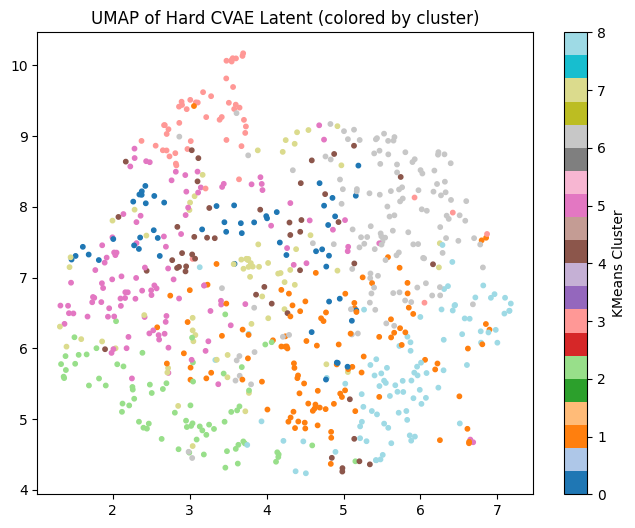

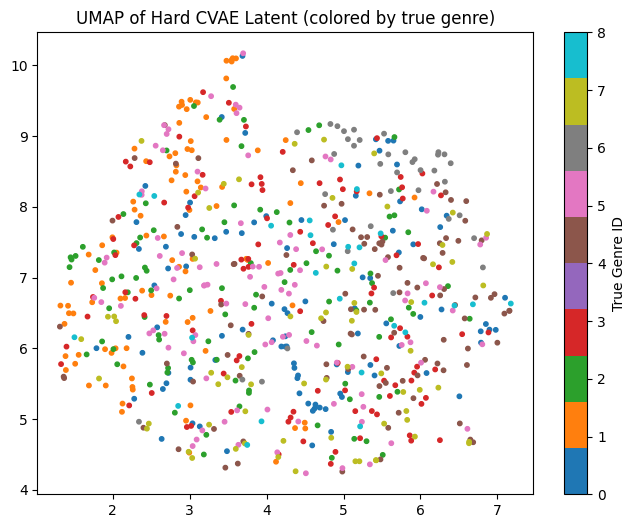

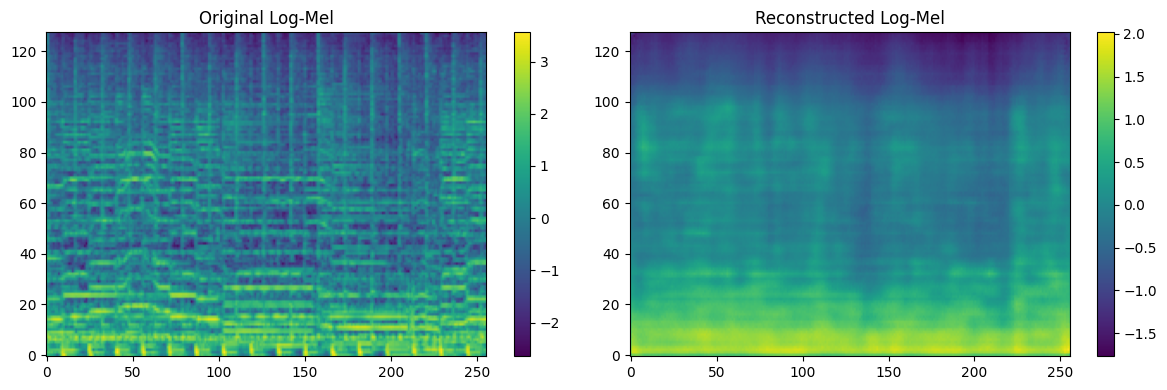

X_csv shape: (729, 58) y_csv shape: (729,)

Baseline: PCA(16) on CSV + KMeans
Silhouette: 0.13977930465341326
Calinski-Harabasz: 100.48548398364119
Davies-Bouldin (lower better): 1.853369800470125
ARI: 0.18326328471775732
NMI: 0.34070769692628405
Purity: 0.4046639231824417
AE epoch 10/50 loss=0.9719
AE epoch 20/50 loss=0.8122
AE epoch 30/50 loss=0.6223
AE epoch 40/50 loss=0.5339
AE epoch 50/50 loss=0.4949

Baseline: Autoencoder(CSV latent) + KMeans
Silhouette: 0.2994764
Calinski-Harabasz: 351.81207
Davies-Bouldin (lower better): 0.9930733262003485
ARI: 0.15364046266380005
NMI: 0.31017352281019606
Purity: 0.37997256515775035


In [ ]:
# -*- coding: utf-8 -*-
"""425_Hard_task.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/137ovynduBRDvXIwqAmc894-_L-0oTK3W
"""

!pip -q install librosa tqdm umap-learn soundfile

import os, random, math
import numpy as np
import pandas as pd
from tqdm import tqdm

import librosa
import soundfile as sf

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)

import umap
import matplotlib.pyplot as plt

!apt-get -qq update
!apt-get -qq install -y ffmpeg libsndfile1

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

GENRES_DIR = "/content/drive/MyDrive/CSE425/genres_original"
CSV_PATH_GIVEN = "/content/drive/MyDrive/CSE425/genres_original"

print("Genres folder exists:", os.path.isdir(GENRES_DIR))

# auto-find features_30_sec.csv inside the project folder
candidate_csvs = [
    CSV_PATH_GIVEN,  # might be wrong (folder)
    os.path.join("/content/drive/MyDrive/CSE425", "fesmall.csv"),
    os.path.join(GENRES_DIR, "fesmall.csv"),
    "/content/drive/MyDrive/CSE425/fesmall.csv",
    "/content/drive/MyDrive/CSE425/new/fesmall.csv"
]

CSV_PATH = None
for p in candidate_csvs:
    if os.path.isfile(p) and p.endswith(".csv"):
        CSV_PATH = p
        break

if CSV_PATH is None:
    # try search in folder
    for root, _, files in os.walk("/content/drive/MyDrive/CSE425"):
        for f in files:
            if f.lower() == "fesmall.csv":
                CSV_PATH = os.path.join(root, f)
                break
        if CSV_PATH: break

print("Resolved CSV_PATH:", CSV_PATH)

assert CSV_PATH is not None, "fesmall.csv not found. Put it in your project folder and rerun."

df = pd.read_csv(CSV_PATH)
print("CSV shape:", df.shape)
print("CSV columns (first 10):", df.columns[:10].tolist())

# GTZAN features csv typically has 'filename' and 'label'
assert "filename" in df.columns, "CSV must have 'filename' column"
assert "label" in df.columns, "CSV must have 'label' column"

# Map filename -> label
csv_label_map = dict(zip(df["filename"].astype(str), df["label"].astype(str)))

print("Example filename:", df["filename"].iloc[0], "label:", df["label"].iloc[0])
print("Unique labels in CSV:", sorted(df["label"].unique())[:10], "... total:", df["label"].nunique())

# list genres from folders
genres = sorted([g for g in os.listdir(GENRES_DIR) if os.path.isdir(os.path.join(GENRES_DIR, g))])
print("Genres in folder:", genres)

audio_items = []
missing_in_csv = 0

for g in genres:
    gpath = os.path.join(GENRES_DIR, g)
    for f in os.listdir(gpath):
        if f.endswith(".wav"):
            # csv stores only filename, like 'blues.00000.wav'
            if f in csv_label_map:
                audio_items.append((os.path.join(gpath, f), csv_label_map[f]))
            else:
                missing_in_csv += 1

print("Audio items aligned with CSV:", len(audio_items))
print("Audio files missing in CSV:", missing_in_csv)

# label encoder
le = LabelEncoder()
all_labels = [lab for _, lab in audio_items]
le.fit(all_labels)
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))
print("num_classes:", num_classes)

def wav_to_logmel(
    file_path,
    sr=22050,
    duration=30.0,
    n_fft=2048,
    hop_length=512,
    n_mels=128,
    fmin=20,
    fmax=8000,
    target_frames=256
):
    try:
        y, _sr = librosa.load(file_path, sr=sr, duration=duration, mono=True)
    except Exception:
        try:
            y, sr_native = sf.read(file_path, always_2d=False)
            if y.ndim > 1:
                y = np.mean(y, axis=1)
            if sr_native != sr:
                y = librosa.resample(y.astype(np.float32), orig_sr=sr_native, target_sr=sr)
        except Exception:
            return None

    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length,
        n_mels=n_mels, fmin=fmin, fmax=fmax, power=2.0
    )
    logmel = librosa.power_to_db(mel, ref=np.max)

    # normalize per-sample
    logmel = (logmel - logmel.mean()) / (logmel.std() + 1e-8)

    T = logmel.shape[1]
    if T < target_frames:
        logmel = np.pad(logmel, ((0,0),(0,target_frames - T)))
    else:
        logmel = logmel[:, :target_frames]

    return logmel.astype(np.float32)[None, :, :]  # (1, 128, 256)

class GTZAN_CVAE_Dataset(Dataset):
    def __init__(self, audio_items, label_encoder):
        self.items = []
        bad = 0
        for path, lab in tqdm(audio_items, desc="Checking audio"):
            x = wav_to_logmel(path)
            if x is None:
                bad += 1
                continue
            y = int(label_encoder.transform([lab])[0])
            self.items.append((path, y))
        self.num_classes = len(label_encoder.classes_)
        print(f"[Dataset] usable={len(self.items)} skipped_bad={bad}")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, y = self.items[idx]
        x = wav_to_logmel(path)
        if x is None:
            x = np.zeros((1,128,256), dtype=np.float32)
        c = np.zeros((self.num_classes,), dtype=np.float32)
        c[y] = 1.0
        return torch.from_numpy(x), torch.tensor(y), torch.from_numpy(c), path

ds = GTZAN_CVAE_Dataset(audio_items, le)

# sanity check
x0, y0, c0, p0 = ds[0]
print("x:", x0.shape, "y:", y0.item(), "c:", c0.shape, "path:", os.path.basename(p0))

N = len(ds)
train_size = int(0.8 * N)
val_size = N - train_size
train_ds, val_ds = random_split(ds, [train_size, val_size], generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train:", len(train_ds), "Val:", len(val_ds))

class ConditionalConvVAE(nn.Module):
    def __init__(self, latent_dim=16, num_classes=10):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        # Encoder CNN: (B,1,128,256) -> (B,256,8,16)
        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),   # 64x128
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),  # 32x64
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(), # 16x32
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU() # 8x16
        )

        self.flat_dim = 256 * 8 * 16

        # condition added before mu/logvar
        self.fc_h = nn.Linear(self.flat_dim + num_classes, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # decoder: latent + condition
        self.fc_dec = nn.Linear(latent_dim + num_classes, self.flat_dim)

        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, c):
        h = self.enc(x).view(x.size(0), -1)
        h = torch.cat([h, c], dim=1)
        h = F.relu(self.fc_h(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)

        zc = torch.cat([z, c], dim=1)
        h2 = self.fc_dec(zc).view(x.size(0), 256, 8, 16)
        x_hat = self.dec(h2)
        return x_hat, mu, logvar, z

def cvae_loss(x, x_hat, mu, logvar, beta=4.0):
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon + beta * kl, recon, kl

LATENT_DIM = 16
BETA = 4.0
LR = 1e-3
EPOCHS = 25

model = ConditionalConvVAE(latent_dim=LATENT_DIM, num_classes=num_classes).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total, total_r, total_k = 0.0, 0.0, 0.0
    nb = 0
    for x, y, c, _ in loader:
        x, c = x.to(device), c.to(device)

        with torch.set_grad_enabled(train):
            x_hat, mu, logvar, _ = model(x, c)
            loss, recon, kl = cvae_loss(x, x_hat, mu, logvar, beta=BETA)

            if train:
                opt.zero_grad()
                loss.backward()
                opt.step()

        total += loss.item()
        total_r += recon.item()
        total_k += kl.item()
        nb += 1

    return total/nb, total_r/nb, total_k/nb

hist = {"train":[], "val":[]}

for ep in range(1, EPOCHS+1):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader, train=False)
    hist["train"].append(tr)
    hist["val"].append(va)
    print(f"Ep {ep:02d}/{EPOCHS} | "
          f"Train L={tr[0]:.2f} (R={tr[1]:.2f}, KL={tr[2]:.2f}) | "
          f"Val L={va[0]:.2f} (R={va[1]:.2f}, KL={va[2]:.2f})")

plt.figure(figsize=(8,5))
plt.plot([x[0] for x in hist["train"]], label="train_total")
plt.plot([x[0] for x in hist["val"]], label="val_total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Hard Task CVAE (beta={BETA}) Training Curve")
plt.legend()
plt.show()

model.eval()

Z_list, Y_list = [], []
loader_all = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)

with torch.no_grad():
    for x, y, c, _ in tqdm(loader_all, total=len(loader_all), desc="Extracting latents"):
        x, c = x.to(device), c.to(device)
        _, mu, _, _ = model(x, c)
        Z_list.append(mu.cpu().numpy())
        Y_list.append(y.numpy())

Z = np.vstack(Z_list)
Y = np.concatenate(Y_list)

print("Z shape:", Z.shape, "Y shape:", Y.shape)

scaler = StandardScaler()
Zs = scaler.fit_transform(Z)
print("Zs mean:", Zs.mean(), "Zs std:", Zs.std())

def cluster_purity(y_true, y_pred):
    # y_true: ints, y_pred: cluster ids
    total = 0
    for k in np.unique(y_pred):
        idx = (y_pred == k)
        if idx.sum() == 0:
            continue
        counts = np.bincount(y_true[idx])
        total += counts.max()
    return total / len(y_true)

def clustering_report(Z_use, y_true, name, y_pred):
    # core cluster metrics
    sil = silhouette_score(Z_use, y_pred) if len(np.unique(y_pred)) > 1 else np.nan
    ch  = calinski_harabasz_score(Z_use, y_pred) if len(np.unique(y_pred)) > 1 else np.nan
    db  = davies_bouldin_score(Z_use, y_pred) if len(np.unique(y_pred)) > 1 else np.nan

    # label-based metrics (evaluation only)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    pur = cluster_purity(y_true, y_pred)

    print(f"\n{name}")
    print("Silhouette:", sil)
    print("Calinski-Harabasz:", ch)
    print("Davies-Bouldin (lower better):", db)
    print("ARI:", ari)
    print("NMI:", nmi)
    print("Purity:", pur)

NUM_CLUSTERS = num_classes

pred_km = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10).fit_predict(Zs)
pred_ag = AgglomerativeClustering(n_clusters=NUM_CLUSTERS, linkage="ward").fit_predict(Zs)

clustering_report(Zs, Y, "Hard CVAE Latent + KMeans", pred_km)
clustering_report(Zs, Y, "Hard CVAE Latent + Agglomerative", pred_ag)

import numpy as np
import matplotlib.pyplot as plt

# Ensure these exist:
# pred_km (KMeans cluster assignments), Y (true genre ids), le (LabelEncoder)

cluster_ids = np.unique(pred_km)
genre_names = le.classes_
n_clusters = len(cluster_ids)
n_genres = len(genre_names)

# Build cluster x genre count matrix
dist = np.zeros((n_clusters, n_genres), dtype=int)

for i, cid in enumerate(cluster_ids):
    idx = (pred_km == cid)
    counts = np.bincount(Y[idx], minlength=n_genres)
    dist[i] = counts

# Plot stacked bar: each cluster shows composition by true genre
plt.figure(figsize=(14,5))
bottom = np.zeros(n_clusters)

for g in range(n_genres):
    plt.bar(cluster_ids, dist[:, g], bottom=bottom, label=genre_names[g])
    bottom += dist[:, g]

plt.title("Cluster Composition by True Genre (Hard CVAE Latent + KMeans)")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Tracks")
plt.xticks(cluster_ids)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Print per-cluster purity + dominant genre
print("\nPer-cluster purity and dominant genre:")
for i, cid in enumerate(cluster_ids):
    total = dist[i].sum()
    dom_idx = dist[i].argmax()
    dom_genre = genre_names[dom_idx]
    purity_i = dist[i, dom_idx] / total if total > 0 else 0.0
    print(f"Cluster {cid:>2}: size={total:>4}  dominant={dom_genre:<10}  purity={purity_i:.3f}")

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
import numpy as np
import torch


BETAS = [1.0, 2.0, 4.0, 6.0]
EPOCHS_SWEEP = 10
LATENT_DIM = 16
LR = 1e-3

def train_cvae_for_beta(beta, epochs=EPOCHS_SWEEP):
    set_seed(42)
    model_b = ConditionalConvVAE(latent_dim=LATENT_DIM, num_classes=num_classes).to(device)
    opt_b = torch.optim.Adam(model_b.parameters(), lr=LR)

    def run_epoch(loader, train=True):
        model_b.train() if train else model_b.eval()
        total = 0.0
        nb = 0
        for x, y, c, _ in loader:
            x, c = x.to(device), c.to(device)
            with torch.set_grad_enabled(train):
                x_hat, mu, logvar, _ = model_b(x, c)
                loss, recon, kl = cvae_loss(x, x_hat, mu, logvar, beta=beta)
                if train:
                    opt_b.zero_grad()
                    loss.backward()
                    opt_b.step()
            total += loss.item()
            nb += 1
        return total / nb

    for ep in range(1, epochs + 1):
        tr = run_epoch(train_loader, train=True)
        va = run_epoch(val_loader, train=False)
        if ep == 1 or ep == epochs or ep % 5 == 0:
            print(f"beta={beta}  ep={ep:02d}/{epochs}  train_loss={tr:.1f}  val_loss={va:.1f}")

    return model_b

def extract_mu(model_b):
    model_b.eval()
    Z_list, Y_list = [], []
    loader_all = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)
    with torch.no_grad():
        for x, y, c, _ in loader_all:
            x, c = x.to(device), c.to(device)
            _, mu, _, _ = model_b(x, c)
            Z_list.append(mu.cpu().numpy())
            Y_list.append(y.numpy())
    Z = np.vstack(Z_list)
    Y = np.concatenate(Y_list)
    return Z, Y

def eval_by_kmeans(Z, Y, k):
    Zs_local = StandardScaler().fit_transform(Z)
    pred = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(Zs_local)

    ari = adjusted_rand_score(Y, pred)
    nmi = normalized_mutual_info_score(Y, pred)
    pur = cluster_purity(Y, pred)
    sil = silhouette_score(Zs_local, pred) if len(np.unique(pred)) > 1 else np.nan

    return {"ARI": ari, "NMI": nmi, "Purity": pur, "Silhouette": sil}

sweep_rows = []
models_by_beta = {}

print("\n====================")
print("β SWEEP START")
print("====================")

for b in BETAS:
    print("\n--------------------")
    print("Training for beta =", b)
    m_b = train_cvae_for_beta(b, epochs=EPOCHS_SWEEP)
    Z_b, Y_b = extract_mu(m_b)
    metrics_b = eval_by_kmeans(Z_b, Y_b, k=num_classes)
    print("Metrics:", metrics_b)
    sweep_rows.append((b, metrics_b))
    models_by_beta[b] = m_b

# Pick best by NMI (primary) then ARI (secondary)
best_beta = sorted(sweep_rows, key=lambda t: (t[1]["NMI"], t[1]["ARI"]), reverse=True)[0][0]
best_metrics = [m for b,m in sweep_rows if b == best_beta][0]

print("\n✅ β SWEEP DONE")
print("Best beta:", best_beta)
print("Best metrics:", best_metrics)

# OPTIONAL: retrain best beta longer for final results (recommended)
RETRAIN_BEST = True
EPOCHS_FINAL = 25

if RETRAIN_BEST:
    print("\n====================")
    print(f"Retraining best beta={best_beta} for {EPOCHS_FINAL} epochs (final model)")
    print("====================")
    final_model = train_cvae_for_beta(best_beta, epochs=EPOCHS_FINAL)
    Z_final, Y_final = extract_mu(final_model)
    final_metrics = eval_by_kmeans(Z_final, Y_final, k=num_classes)
    print("\n✅ FINAL (best beta) metrics:", final_metrics)

    # Save for later cells if you want:
    model = final_model
    Z = Z_final
    Y = Y_final
    Zs = StandardScaler().fit_transform(Z)
    pred_km = KMeans(n_clusters=num_classes, random_state=42, n_init=10).fit_predict(Zs)

um = umap.UMAP(n_components=2, random_state=42)
Z2 = um.fit_transform(Zs)

plt.figure(figsize=(8,6))
plt.scatter(Z2[:,0], Z2[:,1], c=pred_km, s=10, cmap="tab20")
plt.colorbar(label="KMeans Cluster")
plt.title("UMAP of Hard CVAE Latent (colored by cluster)")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(Z2[:,0], Z2[:,1], c=Y, s=10, cmap="tab10")
plt.colorbar(label="True Genre ID")
plt.title("UMAP of Hard CVAE Latent (colored by true genre)")
plt.show()

model.eval()
x, y, c, _ = next(iter(val_loader))
x, c = x.to(device), c.to(device)

with torch.no_grad():
    x_hat, _, _, _ = model(x, c)

x_np  = x[0,0].cpu().numpy()
xh_np = x_hat[0,0].cpu().numpy()

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(x_np, aspect="auto", origin="lower")
plt.title("Original Log-Mel")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(xh_np, aspect="auto", origin="lower")
plt.title("Reconstructed Log-Mel")
plt.colorbar()

plt.tight_layout()
plt.show()

# Prepare CSV feature matrix
df2 = df.copy()
# Keep only rows used in audio_items (aligned filenames)
aligned_files = set([os.path.basename(p) for p,_ in audio_items])
df2 = df2[df2["filename"].astype(str).isin(aligned_files)].reset_index(drop=True)

# X_csv = drop non-numeric + label + filename
drop_cols = ["filename", "label"]
X_csv = df2.drop(columns=[c for c in drop_cols if c in df2.columns])

# keep numeric only
X_csv = X_csv.select_dtypes(include=[np.number]).fillna(0.0).values

y_csv = le.transform(df2["label"].astype(str).values)

print("X_csv shape:", X_csv.shape, "y_csv shape:", y_csv.shape)

X_csvs = StandardScaler().fit_transform(X_csv)
Xp = PCA(n_components=16, random_state=42).fit_transform(X_csvs)

pred_pca_km = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10).fit_predict(Xp)

clustering_report(Xp, y_csv, "Baseline: PCA(16) on CSV + KMeans", pred_pca_km)

class TabularAE(nn.Module):
    def __init__(self, in_dim, latent_dim=16):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, in_dim)
        )

    def forward(self, x):
        z = self.enc(x)
        x_hat = self.dec(z)
        return x_hat, z

X_t = torch.tensor(X_csvs, dtype=torch.float32).to(device)

ae = TabularAE(in_dim=X_csvs.shape[1], latent_dim=16).to(device)
opt2 = torch.optim.Adam(ae.parameters(), lr=1e-3)

for ep in range(1, 51):
    ae.train()
    x_hat, z = ae(X_t)
    loss = F.mse_loss(x_hat, X_t)
    opt2.zero_grad(); loss.backward(); opt2.step()
    if ep % 10 == 0:
        print(f"AE epoch {ep}/50 loss={loss.item():.4f}")

ae.eval()
with torch.no_grad():
    _, Z_ae = ae(X_t)
Z_ae = Z_ae.cpu().numpy()

pred_ae_km = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10).fit_predict(Z_ae)

clustering_report(Z_ae, y_csv, "Baseline: Autoencoder(CSV latent) + KMeans", pred_ae_km)
